In [24]:
import PIL.Image
from pynq.lib.video import *
from pynq import Overlay, allocate
import numpy as np
import cv2

# ol = Overlay("dma_fifo_test.bit")
ol = Overlay("sobel.bit")

In [26]:
frame_h = 720
frame_w = 1280

# for fifo test:
# out_frame_h = 720
# out_frame_w = 1280
# for sobel filter:
out_frame_h = 718
out_frame_w = 1278


videoIn = cv2.VideoCapture(0)
videoIn.set(cv2.CAP_PROP_FRAME_WIDTH, frame_w);
videoIn.set(cv2.CAP_PROP_FRAME_HEIGHT, frame_h);
print("capture device is open: " + str(videoIn.isOpened()))

dma_send = ol.axi_dma_0.sendchannel
dma_recv = ol.axi_dma_0.recvchannel

input_buffer = allocate(shape=(frame_h, frame_w), dtype=np.uint8)
output_buffer = allocate(shape=(out_frame_h, out_frame_w), dtype=np.uint8)

capture device is open: True


[ WARN:0] global ./modules/videoio/src/cap_gstreamer.cpp (616) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


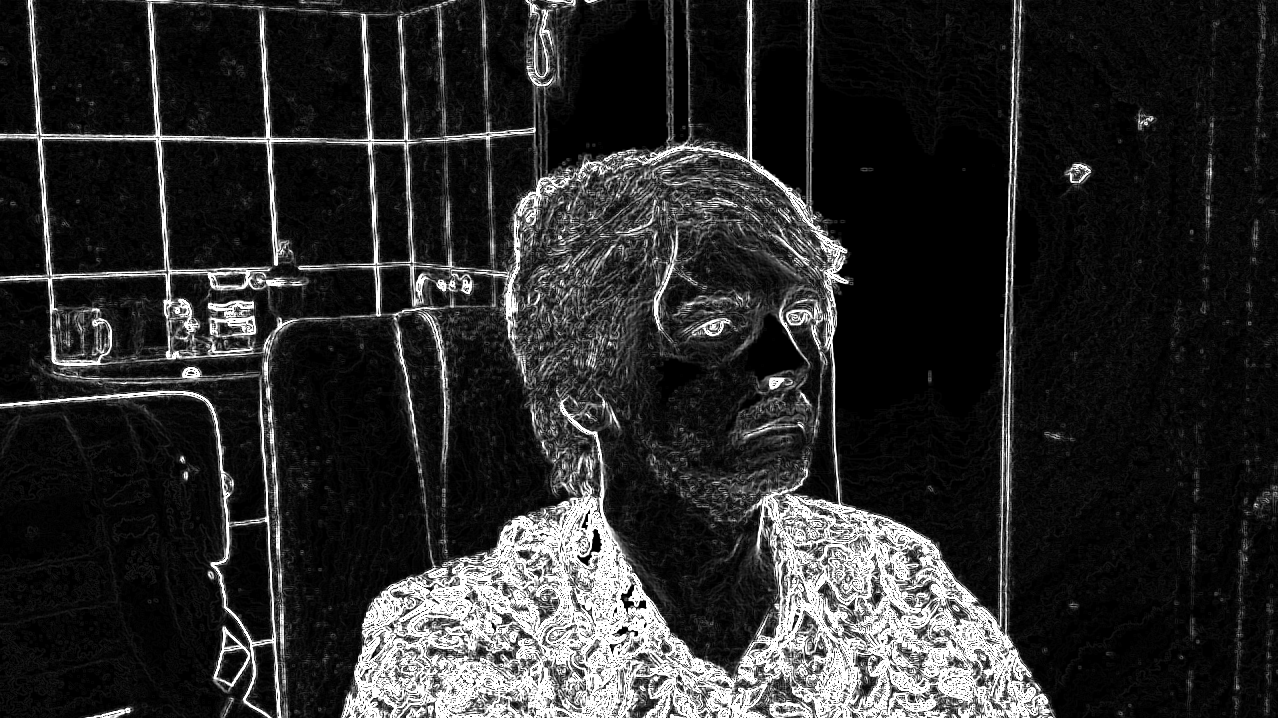

In [27]:
# quick test

ret, frame = videoIn.read()
input_buffer[:] = frame[:, :, 2]
dma_send.transfer(input_buffer)
dma_recv.transfer(output_buffer)
dma_send.wait()
dma_recv.wait()
PIL.Image.fromarray(output_buffer)

In [28]:
import time

displayport = DisplayPort()
displayport.configure(VideoMode(1280, 720, 24), PIXEL_RGB)

for _ in range(3000):
    dp_frame_buffer = displayport.newframe()
    
    ret, frame = videoIn.read()
    
    input_buffer[:] = frame[:, :, 2]
    dma_send.transfer(input_buffer)
    dma_recv.transfer(output_buffer)
    dma_send.wait()
    dma_recv.wait()
    
    dp_frame_buffer[:out_frame_h, :out_frame_w, ] = np.stack([output_buffer, output_buffer, output_buffer], axis=2)
    displayport.writeframe(dp_frame_buffer)

KeyboardInterrupt: 